# Financial Statement Analysis — Microsoft, Tesla & Apple

## Project Overview

This notebook analyses financial data from Microsoft, Tesla and Apple between 2023 and 2025 as part of the BCG GenAI Job Simulation on Forage.

Using Python and pandas, I explored key financial metrics, calculated year-on-year growth rates, compared company performance and visualised financial trends using Matplotlib. The analysis was then used to inform the development of a rule-based financial chatbot.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/10K_financial_data_2023_2025.csv")

In [2]:
df.head

<bound method NDFrame.head of      Company  Fiscal Year Fiscal Year End  Total Revenue ($mm)  \
0  Microsoft         2023      2023-06-30               211915   
1  Microsoft         2024      2024-06-30               245122   
2  Microsoft         2025      2025-06-30               281724   
3      Tesla         2023      2023-12-31                96773   
4      Tesla         2024      2024-12-31                97690   
5      Tesla         2025      2025-12-31                94827   
6      Apple         2023      2023-09-30               383285   
7      Apple         2024      2024-09-28               391035   
8      Apple         2025      2025-09-27               416161   

   Net Income ($mm)  Total Assets ($mm)  Total Liabilities ($mm)  \
0             72361              411976                   205753   
1             88136              512163                   243686   
2            101832              619003                   275524   
3             14974              1066

In [4]:
df.shape

(9, 10)

In [3]:
df.describe()

,Fiscal Year,Total Revenue ($mm),Net Income ($mm),Total Assets ($mm),Total Liabilities ($mm),Operating Cash Flow ($mm)
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,2024.000000,246503.555556,65672.444444,331826.666667,195030.888889,80610.777778
std,0.866025,131525.376877,44143.162463,178905.593674,113610.100337,51270.531241
min,2023.000000,94827.000000,3855.000000,106618.000000,43009.000000,13256.000000
25%,2023.000000,97690.000000,14974.000000,137806.000000,54941.000000,14923.000000
50%,2024.000000,245122.000000,88136.000000,359241.000000,243686.000000,110543.000000
75%,2025.000000,383285.000000,96995.000000,411976.000000,285508.000000,118254.000000
max,2025.000000,416161.000000,112010.000000,619003.000000,308030.000000,136162.000000


In [4]:
df = df[['Company', 'Fiscal Year', 'Fiscal Year End', 'Total Revenue ($mm)',
       'Net Income ($mm)', 'Total Assets ($mm)', 'Total Liabilities ($mm)',
       'Operating Cash Flow ($mm)']].copy()
df

,Company,Fiscal Year,Fiscal Year End,Total Revenue ($mm),Net Income ($mm),Total Assets ($mm),Total Liabilities ($mm),Operating Cash Flow ($mm)
0,Microsoft,2023,2023-06-30,211915,72361,411976,205753,87582
1,Microsoft,2024,2024-06-30,245122,88136,512163,243686,118548
2,Microsoft,2025,2025-06-30,281724,101832,619003,275524,136162
3,Tesla,2023,2023-12-31,96773,14974,106618,43009,13256
4,Tesla,2024,2024-12-31,97690,7153,122070,48390,14923
5,Tesla,2025,2025-12-31,94827,3855,137806,54941,14747
6,Apple,2023,2023-09-30,383285,96995,352583,290437,110543
7,Apple,2024,2024-09-28,391035,93736,364980,308030,118254
8,Apple,2025,2025-09-27,416161,112010,359241,285508,111482


In [5]:
metrics = [
  'Total Revenue ($mm)',
    'Net Income ($mm)',
    'Total Assets ($mm)',
    'Total Liabilities ($mm)',
    'Operating Cash Flow ($mm)'
]

for metric in metrics:
    df[metric + 'Growth']=df.groupby('Company')[metric].pct_change()*100

df

,Company,Fiscal Year,Fiscal Year End,Total Revenue ($mm),Net Income ($mm),Total Assets ($mm),Total Liabilities ($mm),Operating Cash Flow ($mm),Total Revenue ($mm)Growth,Net Income ($mm)Growth,Total Assets ($mm)Growth,Total Liabilities ($mm)Growth,Operating Cash Flow ($mm)Growth
0,Microsoft,2023,2023-06-30,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,2024-06-30,245122,88136,512163,243686,118548,15.669962,21.800417,24.318650,18.436183,35.356580
2,Microsoft,2025,2025-06-30,281724,101832,619003,275524,136162,14.932156,15.539621,20.860546,13.065174,14.858117
3,Tesla,2023,2023-12-31,96773,14974,106618,43009,13256,NaN,NaN,NaN,NaN,NaN
4,Tesla,2024,2024-12-31,97690,7153,122070,48390,14923,0.947578,-52.230533,14.492862,12.511335,12.575438
5,Tesla,2025,2025-12-31,94827,3855,137806,54941,14747,-2.930699,-46.106529,12.890964,13.537921,-1.179388
6,Apple,2023,2023-09-30,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
7,Apple,2024,2024-09-28,391035,93736,364980,308030,118254,2.021994,-3.359967,3.516052,6.057424,6.975566
8,Apple,2025,2025-09-27,416161,112010,359241,285508,111482,6.425512,19.495178,-1.572415,-7.311625,-5.726656


In [8]:
growth_columns = [
    'Total Revenue ($mm)Growth',
    'Net Income ($mm)Growth',
    'Total Assets ($mm)Growth',
    'Total Liabilities ($mm)Growth',
    'Operating Cash Flow ($mm)Growth'
]

df[growth_columns] = df[growth_columns].round(2)
df

,Company,Fiscal Year,Fiscal Year End,Total Revenue ($mm),Net Income ($mm),Total Assets ($mm),Total Liabilities ($mm),Operating Cash Flow ($mm),Total Revenue ($mm)Growth,Net Income ($mm)Growth,Total Assets ($mm)Growth,Total Liabilities ($mm)Growth,Operating Cash Flow ($mm)Growth
0,Microsoft,2023,2023-06-30,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
1,Microsoft,2024,2024-06-30,245122,88136,512163,243686,118548,15.67,21.80,24.32,18.44,35.36
2,Microsoft,2025,2025-06-30,281724,101832,619003,275524,136162,14.93,15.54,20.86,13.07,14.86
3,Tesla,2023,2023-12-31,96773,14974,106618,43009,13256,NaN,NaN,NaN,NaN,NaN
4,Tesla,2024,2024-12-31,97690,7153,122070,48390,14923,0.95,-52.23,14.49,12.51,12.58
5,Tesla,2025,2025-12-31,94827,3855,137806,54941,14747,-2.93,-46.11,12.89,13.54,-1.18
6,Apple,2023,2023-09-30,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
7,Apple,2024,2024-09-28,391035,93736,364980,308030,118254,2.02,-3.36,3.52,6.06,6.98
8,Apple,2025,2025-09-27,416161,112010,359241,285508,111482,6.43,19.50,-1.57,-7.31,-5.73


In [9]:
for metric in metrics:
    table = df.pivot(
        index='Fiscal Year',
        columns='Company',
        values=metric
    )
    
    print(metric)
    display(table)

Total Revenue ($mm)


Company,Apple,Microsoft,Tesla
Fiscal Year,,,
2023,383285,211915,96773
2024,391035,245122,97690
2025,416161,281724,94827


Net Income ($mm)


Company,Apple,Microsoft,Tesla
Fiscal Year,,,
2023,96995,72361,14974
2024,93736,88136,7153
2025,112010,101832,3855


Total Assets ($mm)


Company,Apple,Microsoft,Tesla
Fiscal Year,,,
2023,352583,411976,106618
2024,364980,512163,122070
2025,359241,619003,137806


Total Liabilities ($mm)


Company,Apple,Microsoft,Tesla
Fiscal Year,,,
2023,290437,205753,43009
2024,308030,243686,48390
2025,285508,275524,54941


Operating Cash Flow ($mm)


Company,Apple,Microsoft,Tesla
Fiscal Year,,,
2023,110543,87582,13256
2024,118254,118548,14923
2025,111482,136162,14747


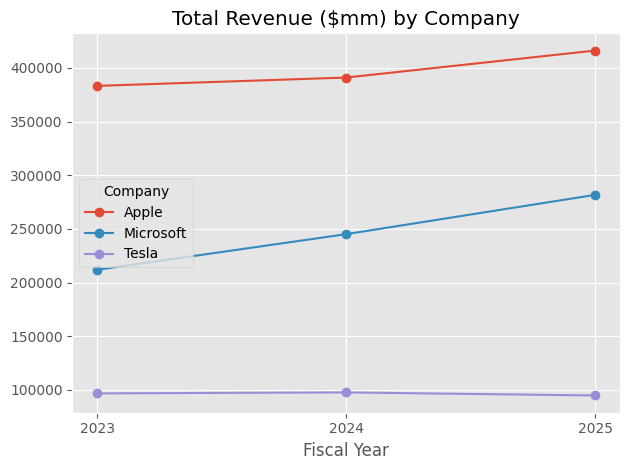

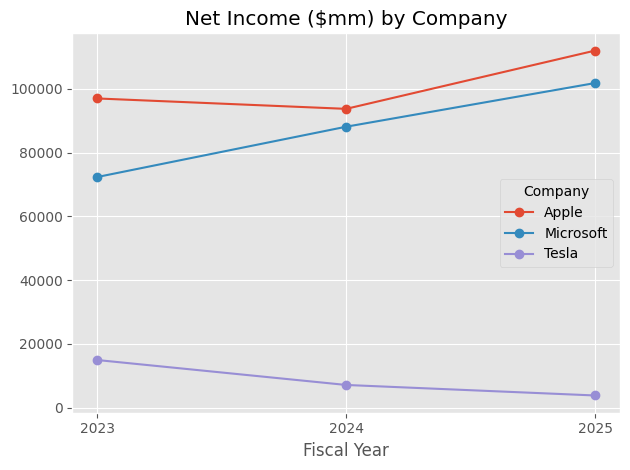

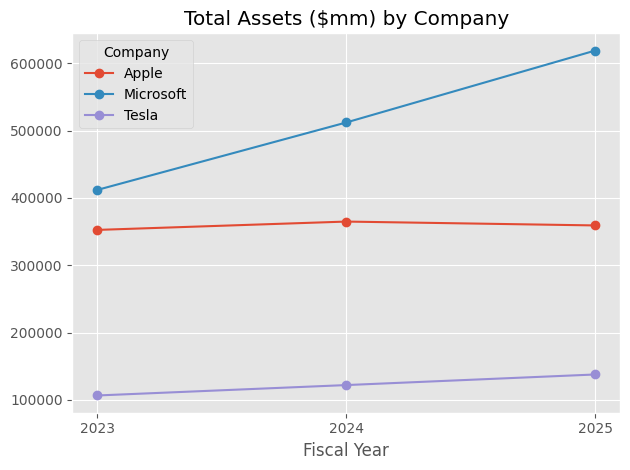

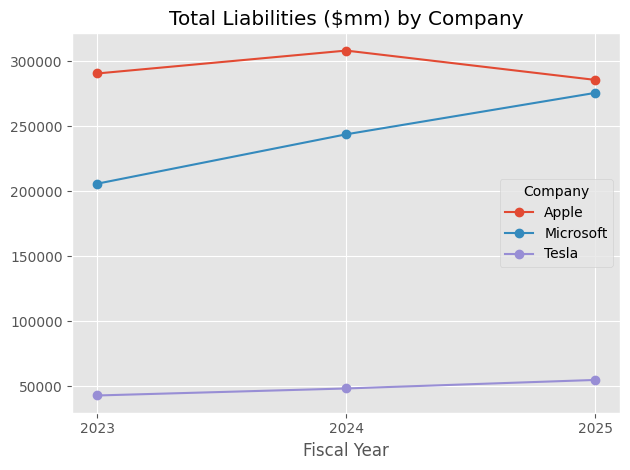

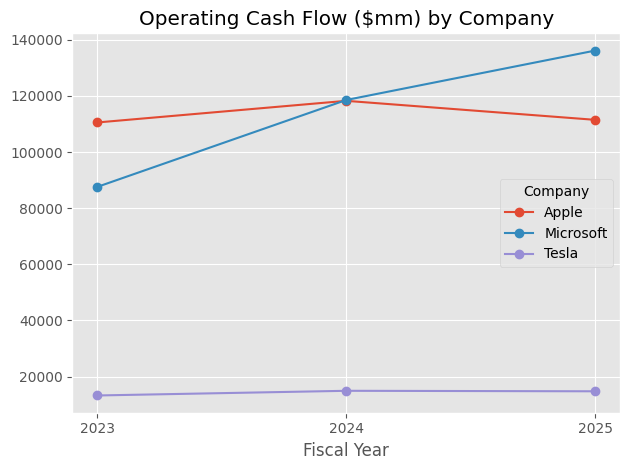

In [10]:
for metric in metrics:
    table = df.pivot(
        index='Fiscal Year',
        columns='Company',
        values=metric
    )

    table.plot(marker='o')
    plt.title(metric + ' by Company')
    plt.xlabel('Fiscal Year')
    plt.xticks([2023, 2024, 2025])
    plt.tight_layout()
    plt.show()

## Financial Trend Analysis

To compare the financial performance of Microsoft, Tesla and Apple from 2023 to 2025, I analysed revenue, net income, total assets, total liabilities and operating cash flow.

Using pandas, I calculated year-on-year percentage changes for each company and used Matplotlib to visualise trends across the three-year period.

**Revenue:** Microsoft demonstrated the strongest and most consistent revenue growth, increasing by approximately 15% in both 2024 and 2025. Apple recorded more moderate growth, which accelerated in 2025, while Tesla’s revenue remained almost flat in 2024 before declining in 2025.

**Net income:** Microsoft maintained strong net income growth across both years. Apple experienced a small decline in 2024 before recovering strongly in 2025. In contrast, Tesla’s net income fell substantially in both years, representing the weakest profitability trend among the three companies.

**Total assets:** Microsoft and Tesla expanded their asset bases throughout the period, with Microsoft recording the stronger growth. Apple’s total assets increased slightly in 2024 before declining modestly in 2025.

**Total liabilities:** Microsoft and Tesla both recorded increases in total liabilities across the period. Apple’s liabilities increased in 2024 before decreasing in 2025.

**Operating cash flow:** Microsoft demonstrated the strongest operating cash flow growth, including substantial growth in 2024 followed by further growth in 2025. Apple and Tesla generated positive growth in 2024 but both experienced declines in operating cash flow in 2025.

## Conclusion

Overall, Microsoft demonstrated the strongest and most consistent growth across the five financial metrics analysed. Apple showed more moderate performance, with stronger revenue and net income growth in 2025, although total assets and operating cash flow declined. Tesla showed the weakest overall financial trends, with declining revenue in 2025 and substantial reductions in net income across both years, despite continued growth in its asset base.

## Application to the Financial Chatbot

This analysis demonstrates how financial data from 10-K filings can be processed to identify trends rather than simply report individual figures. An AI-powered financial chatbot could use calculations such as year-on-year growth to answer questions about company performance, compare companies and highlight significant changes in financial metrics. This would allow users to obtain concise, data-driven insights from financial statements.